Multiple Inputs Graph

In [2]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [3]:
class AgentState(TypedDict):
   values: List[int]
   name: str
   result: str

In [4]:
def process_values(state: AgentState) -> AgentState:
    """This function handles multiple different inputs"""

    total = sum(state["values"])
    state["result"] = f"The total for {state['name']} is {total}"
    return state

In [8]:
graph = StateGraph(AgentState)

graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()

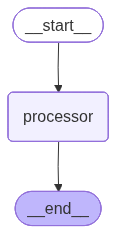

In [9]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))


In [10]:
result = app.invoke({"values": [10, 20 ,30], "name": "Sample Data"})

In [11]:
result["result"]

'The total for Sample Data is 60'